In [3]:
!pip install scikit-learn



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import sklearn

In [8]:
data = pd.DataFrame({'Price_USA':[80,50,140,25],
                     'Price_INR':[5000,7000,12000,3000]})
data

,Price_USA,Price_INR
0,80,5000
1,50,7000
2,140,12000
3,25,3000


In [9]:
# We will perform mathematical wise
data['Price_USA_minmax']=(data['Price_USA'] - data['Price_USA'].min()) / (data['Price_USA'].max() - data['Price_USA'].min())
data

,Price_USA,Price_INR,Price_USA_minmax
0,80,5000,0.478261
1,50,7000,0.217391
2,140,12000,1.000000
3,25,3000,0.000000


In [10]:
# We will perform mathematical wise
data['Price_INR_minmax']=(data['Price_INR'] - data['Price_INR'].min()) / (data['Price_INR'].max() - data['Price_INR'].min())
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax
0,80,5000,0.478261,0.222222
1,50,7000,0.217391,0.444444
2,140,12000,1.000000,1.000000
3,25,3000,0.000000,0.000000


In [11]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [12]:
min_max = MinMaxScaler()

In [13]:
#We need to use fit_transform()
data['Price_USA_minsk'] = min_max.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk
0,80,5000,0.478261,0.222222,0.478261
1,50,7000,0.217391,0.444444,0.217391
2,140,12000,1.000000,1.000000,1.000000
3,25,3000,0.000000,0.000000,0.000000


In [16]:
#We need to use fit_transform()
data['Price_INR_minsk'] = min_max.fit_transform(data[['Price_INR']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk,Price_INR_minsk
0,80,5000,0.478261,0.222222,0.478261,0.222222
1,50,7000,0.217391,0.444444,0.217391,0.444444
2,140,12000,1.000000,1.000000,1.000000,1.000000
3,25,3000,0.000000,0.000000,0.000000,0.000000


In [21]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
!pip install ucimlrepo


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer 
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [24]:
#Step 2: Loading (autompg dataset) and Cleaning the Data
data = fetch_ucirepo(id = 9)
data
X = data.data.features.copy()
y = data.data.targets['mpg']
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [25]:
import ssl
import urllib.request

In [26]:
X.describe()
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [27]:
X['origin'].unique();
X['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [28]:
#first we will transform the hp and origin columns
X['horsepower'] = pd.to_numeric(X['horsepower'],errors='coerce')
#X['horsepower'].info()
X['origin'] = X['origin'].astype(str)

In [29]:
X.info();
#All numerical columns into a single collections
numerical_features = ['cylinders','displacement','horsepower','weight','acceleration','model_year']
categorical_features =['origin']
X = X[numerical_features + categorical_features]
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    str    
dtypes: float64(3), int64(3), str(1)
memory usage: 21.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 n

In [30]:
#Step 3 : Quick Exploratory Data Analysis (Seaborn)
df = X.copy()
df['mpg'] = y
#here we are mapping input and target variable into the dataframe

Text(0.5, 1.0, 'Weight vs MPG')

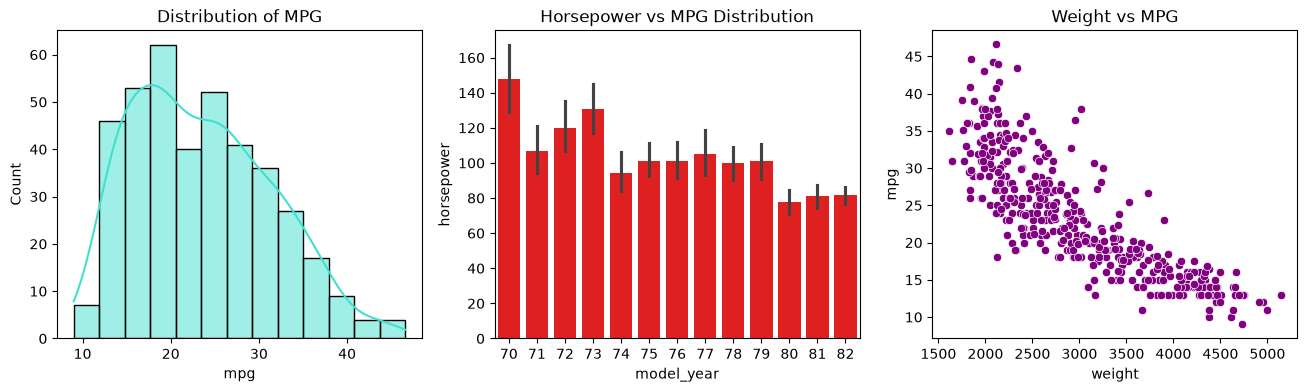

In [31]:
#df
#We are gonna use subplots() concept to divide the plot into multiple plots
fig,axes = plt.subplots(1,3,figsize=(16,4))
#plot graphs as per axes
sns.histplot(df['mpg'],kde=True,ax=axes[0],color = 'turquoise')
axes[0].set_title("Distribution of MPG")
sns.barplot(x=df['model_year'],y=df['horsepower'],ax=axes[1],color='red')
axes[1].set_title("Horsepower vs MPG Distribution")
sns.scatterplot(x=df['weight'],y=df['mpg'],ax=axes[2],color='purple')
axes[2].set_title("Weight vs MPG")

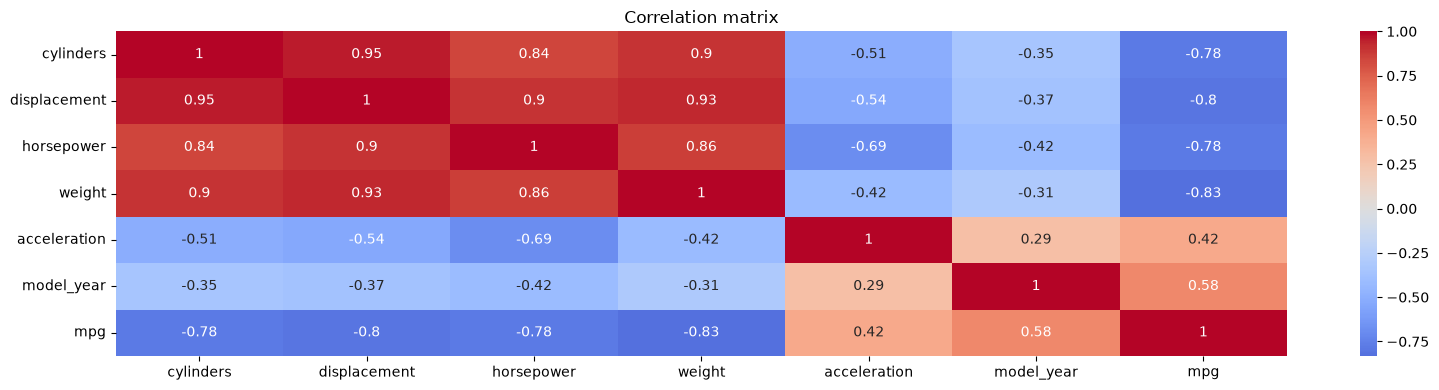

In [32]:
#Correlation between our variables (positive correlation/negative correlation)
plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            center=0
           )
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [33]:
#Step 4: Dividing the data into train test split
#print(X)
#print(y)
#SPlit rule -->70-30,80-20,75-25
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('\nTrain test Split')
print("Training Data",len(X_train))
print("Testing Data",len(X_test))
#print(X_train)


Train test Split
Training Data 318
Testing Data 80


In [34]:
#Step 5 : Creating an Evaluation Function for baseline model
def evaluate(model_name,actual,predicted):
    """Returns MAE,MSE,RMSE,R2-Score"""
    mse = mean_squared_error(actual,predicted)
    mae = mean_absolute_error(actual,predicted)
    return {'Model_Name': model_name,
    'MAE':mae,
    'MSE':mse,
    'RMSE':np.sqrt(mse),
    'R2-Score':r2_score(actual,predicted)}
results =[]

In [35]:
#Step 6 : Baseline model -->It predicts the training set for every values
baseline_predictions =np.full(len(y_test),y_train.mean())
#baseline_predictions
#in above case we are keeping a baseline prediction
results.append(evaluate("Mean baseline",y_test,baseline_predictions))
#results
# in above case we are creating the baseline predicted data

In [36]:
#Step7: We apply Linear Regression
simple_model = LinearRegression()
#we fit the data the model
simple_model.fit(X_train[['weight']],y_train)
simple_model_predictions = simple_model.predict(X_test[['weight']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression:Weight",
                        y_test,
                        simple_model_predictions))
print(len(results))

2


In [37]:
results

[{'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': 3.1177861992064573,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075}]

In [38]:
#we will check the intercept value
print(f'Simple Linear Regression Equation')
print(f"Predicted MPG = {simple_model.intercept_}+({simple_model.coef_[0]})*weight")

Simple Linear Regression Equation
Predicted MPG = 46.78206336645047+(-0.007805242351594879)*weight
